In [115]:
!pip install python-sat

##  Import libraries

- `numpy as np`: Numerical computations.
- `math`: Standard math functions.
- `itertools as it`: Combinatorics tools (e.g. product, permutations).
- `Glucose3` (from `pysat.solvers`): SAT solver.
- `CNF` (from `pysat.formula`): CNF formula handling.
- `matplotlib.pyplot as plt`: Plotting.
- `matplotlib.patches`: Drawing shapes (e.g. rectangles).
- `Enum` (from `enum`): Define constant groups.


In [116]:
import numpy as np
import math
import itertools as it
from pysat.solvers import Glucose3
from pysat.formula import CNF
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from enum import Enum

###**CellColor**


## **CellColor**

The `CellColor` class is an `Enum` that defines the possible color states of a cell on the grid, representing logical assignments in a CSP (Constraint Satisfaction Problem).

- **`RED = False`**: Indicates that the cell is assigned `False`, typically visualized as red.
- **`GREEN = True`**: Indicates that the cell is assigned `True`, typically visualized as green.
- **`UNDEFINED = None`**: Indicates that the cell has not yet been assigned a value.

This enumeration improves code clarity and is especially useful when visualizing grid solutions with distinct cell states.


In [117]:
class CellColor(Enum):
  """Enumeration for cell colors"""
  RED = False
  GREEN = True
  UNDEFINED = None

##**Position**
The `Position` class represents a cell's coordinates on the grid, defined by row and column.

- **`__init__(self, row, col)`**: Initializes a position with given row and column indices.
- **`__eq__(self, other)`**: Checks whether two positions are equal.
- **`__hash__(self)`**: Enables use of `Position` instances as dictionary keys.
- **`__repr__(self)`**: Returns a string representation of the position.



In [118]:
class Position:
    """Position representation for grid coordinates"""

    def __init__(self, row, col):
        self.row = row
        self.col = col

    def __eq__(self, other):
        return self.row == other.row and self.col == other.col

    def __hash__(self):
        return hash((self.row, self.col))

    def __repr__(self):
        return f"Position({self.row}, {self.col})"

##**Variable**
The `Variable` class represents a CSP variable with an ID, position, and possible boolean assignment.

- **`__init__(self, var_id, position)`**: Initializes a variable with a unique ID and grid position.
- **`is_assigned(self)`**: Checks whether the variable has been assigned a value.
- **`assign(self, value)`**: Assigns a boolean value to the variable.
- **`__repr__(self)`**: Returns a string representation of the variable.


In [119]:
class Variable:
    """Represents a CSP variable with domain and assignment"""

    def __init__(self, var_id, position):
        self.id = var_id
        self.position = position
        self.assignment = None

    def is_assigned(self):
        return self.assignment is not None

    def assign(self, value):
        self.assignment = value

    def __repr__(self):
      return f"Variable(id={self.id}, pos={self.position}, val={self.assignment})"

##**Cell**
The `Cell` class represents a grid cell that may contain a constraint and be associated with a variable.

- **`__init__(self, position, k_value=None)`**: Initializes the cell with its position and an optional constraint value.
- **`has_constraint(self)`**: Returns `True` if the cell has a constraint.
- **`get_color(self)`**: Returns the cell's color based on its variable's assignment.
- **`__repr__(self)`**: Returns a string representation of the cell.


In [120]:
class Cell:
    """Enhanced Cell class representing grid cells"""

    def __init__(self, position, k_value=None):
        self.position = position
        self.k_value = k_value if not (k_value is not None
                                       and math.isnan(k_value)) else None
        self.variable = None

    def has_constraint(self):
        return self.k_value is not None

    def get_color(self):
        if self.variable and self.variable.is_assigned():
            return CellColor.GREEN if self.variable.assignment else CellColor.RED
        return CellColor.UNDEFINED

    def __repr__(self):
        return f"Cell(pos={self.position}, k={self.k_value}, color={self.get_color()})"

##**ExactlyKConstraint**
The `ExactlyKConstraint` class enforces that exactly `k` variables out of a set are assigned `True`.

- **`__init__(self, variable_ids, k)`**: Initializes the constraint with a set of variable IDs and target count `k`.
- **`generate_cnf_clauses(self)`**: Generates CNF clauses representing the constraint.
- **`is_satisfied(self, assignment)`**: Checks if the current assignment satisfies the constraint.


In [121]:
class ExactlyKConstraint:
    """Constraint ensuring exactly k variables are true"""

    def __init__(self, variable_ids, k):
        self.variable_ids = variable_ids
        self.k = k
        self.num_vars = len(variable_ids)

    def generate_cnf_clauses(self):
        """Generate CNF clauses for exactly-k constraint"""
        clauses = []

        # At least k true
        if self.k > 0:
            for combo in it.combinations(self.variable_ids,
                                         self.num_vars - self.k + 1):
                clauses.append(list(combo))

        # At most k true
        if self.k < self.num_vars:
            for combo in it.combinations(self.variable_ids, self.k + 1):
                clauses.append([-var_id for var_id in combo])

        return clauses

    def is_satisfied(self, assignment):
        """Check if current assignment satisfies this constraint"""
        true_count = sum(1 for var_id in self.variable_ids
                        if var_id in assignment and assignment[var_id])
        return true_count == self.k

##**Grid**
The `Grid` class represents the puzzle environment using a 2D layout of cells.

- **`load_from_file(self, filepath)`**: Loads grid data from a file into cells.
- **`get_neighbors(self, position)`**: Returns all 8-connected neighbors of a cell, including the center.
- **`get_all_cells(self)`**: Returns all cells in the grid in row-major order.


In [122]:
class Grid:
    """Grid representation with Moore neighborhood topology"""

    def __init__(self):
        self.cells = {}
        self.dimensions = (0, 0)

    def load_from_file(self, filepath):
        """Load grid data from file"""
        try:
            data = np.genfromtxt(
                filepath,
                dtype=float,
                missing_values='.',
                filling_values=np.nan,
                delimiter=' ',
                comments='#'
            )
        except Exception as e:
            print(f"Error loading file {filepath}: {e}")
            return False

        # Handle different array dimensions
        if data.ndim == 0:
            data = np.array([[data.item()]])
        elif data.ndim == 1:
            data = np.array([data])

        self.dimensions = data.shape
        rows, cols = self.dimensions

        # Create cells
        for r in range(rows):
            for c in range(cols):
                pos = Position(r, c)
                k_val = None if math.isnan(data[r, c]) else int(data[r, c])
                self.cells[pos] = Cell(pos, k_val)

        print(f"Successfully loaded grid: {rows}x{cols}")
        return True

    def get_neighbors(self, position):
        """Get 8-connected Moore neighborhood including center"""
        neighbors = []
        rows, cols = self.dimensions

        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                nr, nc = position.row + dr, position.col + dc
                if 0 <= nr < rows and 0 <= nc < cols:
                    neighbor_pos = Position(nr, nc)
                    if neighbor_pos in self.cells:
                        neighbors.append(self.cells[neighbor_pos])

        return neighbors

    def get_all_cells(self):
        """Get all cells in row-major order"""
        rows, cols = self.dimensions
        cells = []
        for r in range(rows):
            for c in range(cols):
                pos = Position(r, c)
                if pos in self.cells:
                    cells.append(self.cells[pos])
        return cells

##**CSPSolver**
The `CSPSolver` class encodes and solves the constraint satisfaction problem using a SAT solver.

- **`setup_problem(self, grid)`**: Initializes variables and constraints based on the input grid.
- **`solve(self)`**: Encodes the problem as SAT and attempts to find a solution.
- **`verify_solution(self)`**: Validates the found solution against all constraints.
- **`evaluate_solution(self, grid)`**: Provides evaluation statistics of the solution over the grid.


In [123]:
class CSPSolver:
    """Main CSP solver using SAT encoding"""

    def __init__(self):
        self.variables = {}
        self.constraints = []
        self.solution = None

    def setup_problem(self, grid):
        """Setup CSP variables and constraints from grid"""
        # Create variables
        var_id = 1
        for cell in grid.get_all_cells():
            variable = Variable(var_id, cell.position)
            cell.variable = variable
            self.variables[var_id] = variable
            var_id += 1

        # Create constraints
        for cell in grid.get_all_cells():
          if cell.has_constraint():
            neighbors = grid.get_neighbors(cell.position)
            neighbor_var_ids = [n.variable.id for n in neighbors if n.variable]

            if neighbor_var_ids:
                constraint = ExactlyKConstraint(neighbor_var_ids, cell.k_value)
                self.constraints.append(constraint)
        tempstr = f"{len(self.constraints)} constraints"
        print(f"Setup complete: {len(self.variables)} variables, " + tempstr)

    def solve(self):
        """Solve the CSP using SAT solver"""
        if not self.constraints:
            print("No constraints found. Setting all cells to RED.")
            for var in self.variables.values():
                var.assign(False)
            return True

        # Generate all CNF clauses
        all_clauses = []
        for constraint in self.constraints:
            all_clauses.extend(constraint.generate_cnf_clauses())

        if not all_clauses:
            print("No clauses generated. Problem trivially satisfiable.")
            return True

        # Solve using Glucose SAT solver
        formula = CNF()
        for clause in all_clauses:
            formula.append(clause)

        solver = Glucose3()
        solver.append_formula(formula.clauses)

        is_sat = solver.solve()

        if is_sat:
            model = solver.get_model()
            assignment = {}
            for lit in model:
                assignment[abs(lit)] = lit > 0

            # Update variable assignments
            for var_id, value in assignment.items():
                if var_id in self.variables:
                    self.variables[var_id].assign(value)

            self.solution = assignment
            print("Solution found!")
            return True
        else:
            print("No solution exists (UNSATISFIABLE)")
            return False

    def verify_solution(self):
        """Verify the current solution against all constraints"""
        if not self.solution:
            return False, ["No solution to verify"]

        violations = []
        for i, constraint in enumerate(self.constraints):
            if not constraint.is_satisfied(self.solution):
                violations.append(f"Constraint {i} violated")

        is_valid = len(violations) == 0
        return is_valid, violations

    def evaluate_solution(self, grid):
        """Evaluate and print solution statistics"""
        if not self.solution:
            print("No solution to evaluate")
            return

        print("\n=== Solution Evaluation ===")
        print(f"Grid size: {grid.dimensions[0]}x{grid.dimensions[1]}")
        print(f"Variables: {len(self.variables)}")
        print(f"Constraints: {len(self.constraints)}")

        correct_count = 0
        total_constraints = 0

        for cell in grid.get_all_cells():
            if cell.has_constraint():
                total_constraints += 1
                neighbors = grid.get_neighbors(cell.position)
                actual_green = sum(1 for n in neighbors
                                   if n.get_color() == CellColor.GREEN)
                expected = cell.k_value

                is_correct = actual_green == expected
                if is_correct:
                    correct_count += 1

                status = "CORRECT" if is_correct else "INCORRECT"
                tempstr2 = f"actual={actual_green} - {status}"
                print(f"Cell{cell.position}: k={expected}, "+ tempstr2)

        if total_constraints > 0:
            accuracy = (correct_count / total_constraints) * 100
            tempstr3 = f"({correct_count}/{total_constraints})"
            print(f"\nAccuracy: {accuracy:.1f}% " + tempstr3)
        else:
            print("\nNo constraints to evaluate")

##**GridVisualizer**
The `GridVisualizer` class provides tools to display the colored grid using matplotlib.

- **`__init__(self, cell_size=0.7)`**: Initializes the visualizer with a specific cell size.
- **`visualize(self, grid, title="Grid Coloring Solution")`**: Displays the grid with cell colors and constraint values.


In [124]:
class GridVisualizer:
    """Visualizes grid solutions using matplotlib"""

    def __init__(self, cell_size=0.7):
        self.cell_size = cell_size

    def visualize(self, grid, title="Grid Coloring Solution"):
        """Visualize the grid with current cell colors"""
        rows, cols = grid.dimensions
        if rows == 0 or cols == 0:
            print("No grid to visualize")
            return

        fig, ax = plt.subplots(figsize=(cols * self.cell_size,
                                        rows * self.cell_size))
        ax.set_xlim(0, cols)
        ax.set_ylim(0, rows)

        # Setup grid lines
        ax.set_xticks(np.arange(cols + 1))
        ax.set_yticks(np.arange(rows + 1))
        ax.grid(True, color='black', linewidth=0.5)
        ax.tick_params(bottom=False, top=False, left=False, right=False,
                      labelbottom=False, labelleft=False)
        ax.invert_yaxis()

        # Color mapping
        color_map = {
            CellColor.GREEN: 'green',
            CellColor.RED: 'red',
            CellColor.UNDEFINED: 'lightgray'
        }

        # Draw cells
        for cell in grid.get_all_cells():
            pos = cell.position
            face_color = color_map[cell.get_color()]

            rect = patches.Rectangle((pos.col, pos.row), 1, 1,
                                   facecolor=face_color,
                                     edgecolor='black', linewidth=0.5)
            ax.add_patch(rect)

            # Add k-value text if present
            if cell.has_constraint():
                text_color = 'white' if cell.get_color() != CellColor.UNDEFINED else 'black'
                ax.text(pos.col + 0.5, pos.row + 0.5, str(cell.k_value),
                       color=text_color, ha='center', va='center',
                       fontsize=9, fontweight='bold')

        # Add legend
        legend_patches = [
            patches.Patch(facecolor='limegreen', edgecolor='black',
                          label='Green (True)'),
            patches.Patch(facecolor='salmon', edgecolor='black',
                          label='Red (False)'),
            patches.Patch(facecolor='lightgray', edgecolor='black',
                          label='Undefined')
        ]
        ax.legend(handles=legend_patches, loc='upper center',
                  bbox_to_anchor=(0.5, -0.03),
                 ncol=3, fontsize='small')

        plt.title(title)
        plt.tight_layout()
        plt.show()

##**GridColoringApplication**
The `GridColoringApplication` class serves as the main controller, coordinating grid setup, solving, and visualization.

- **`__init__(self)`**: Initializes the application components (grid, solver, visualizer).
- **`run(self, input_file)`**: Executes the full solving pipeline from input to visualization.


In [125]:
class GridColoringApplication:
    """Main application facade"""

    def __init__(self):
        self.grid = Grid()
        self.solver = CSPSolver()
        self.visualizer = GridVisualizer()

    def run(self, input_file):
        """Main execution flow"""
        print("=== AI Grid Coloring CSP Solver ===")

        # Load problem
        if not self.grid.load_from_file(input_file):
            print("Failed to load input file")
            return

        # Setup and solve
        self.solver.setup_problem(self.grid)

        if self.solver.solve():
            # Verify solution
            is_valid, violations = self.solver.verify_solution()
            if is_valid:
                print("Solution verified successfully!")
            else:
                print(f"Solution verification failed: {violations}")

            # Show results
            self.visualizer.visualize(self.grid)
            self.solver.evaluate_solution(self.grid)
        else:
            print("No solution found. Showing current grid state:")
            self.visualizer.visualize(self.grid, "Unsolved Grid")


##**Testing And Evaluating the Result**

###**Providing Testcase**

=== AI Grid Coloring CSP Solver ===
Successfully loaded grid: 10x10
Setup complete: 100 variables, 36 constraints
Solution found!
Solution verified successfully!


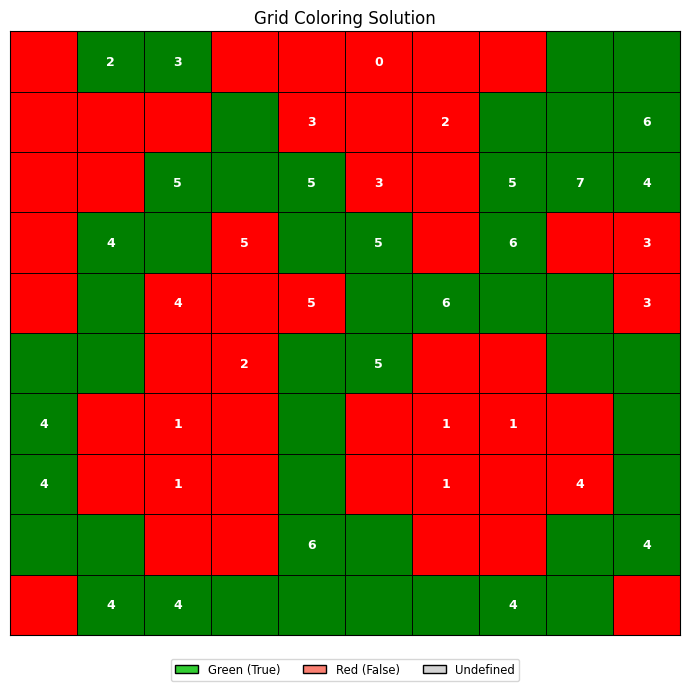


=== Solution Evaluation ===
Grid size: 10x10
Variables: 100
Constraints: 36
CellPosition(0, 1): k=2, actual=2 - CORRECT
CellPosition(0, 2): k=3, actual=3 - CORRECT
CellPosition(0, 5): k=0, actual=0 - CORRECT
CellPosition(1, 4): k=3, actual=3 - CORRECT
CellPosition(1, 6): k=2, actual=2 - CORRECT
CellPosition(1, 9): k=6, actual=6 - CORRECT
CellPosition(2, 2): k=5, actual=5 - CORRECT
CellPosition(2, 4): k=5, actual=5 - CORRECT
CellPosition(2, 5): k=3, actual=3 - CORRECT
CellPosition(2, 7): k=5, actual=5 - CORRECT
CellPosition(2, 8): k=7, actual=7 - CORRECT
CellPosition(2, 9): k=4, actual=4 - CORRECT
CellPosition(3, 1): k=4, actual=4 - CORRECT
CellPosition(3, 3): k=5, actual=5 - CORRECT
CellPosition(3, 5): k=5, actual=5 - CORRECT
CellPosition(3, 7): k=6, actual=6 - CORRECT
CellPosition(3, 9): k=3, actual=3 - CORRECT
CellPosition(4, 2): k=4, actual=4 - CORRECT
CellPosition(4, 4): k=5, actual=5 - CORRECT
CellPosition(4, 6): k=6, actual=6 - CORRECT
CellPosition(4, 9): k=3, actual=3 - CORRECT

In [126]:
app = GridColoringApplication()
app.run('input.txt')


###**Random satisfying Testcase**

=== AI Grid Coloring CSP Solver ===
Successfully loaded grid: 6x6
Setup complete: 36 variables, 2 constraints
Solution found!
Solution verified successfully!


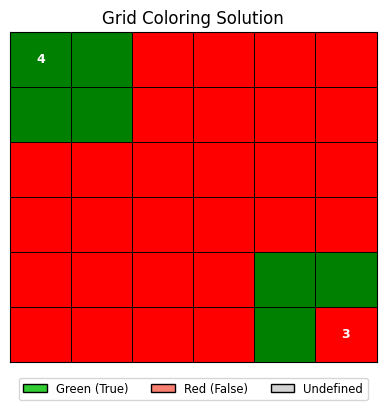


=== Solution Evaluation ===
Grid size: 6x6
Variables: 36
Constraints: 2
CellPosition(0, 0): k=4, actual=4 - CORRECT
CellPosition(5, 5): k=3, actual=3 - CORRECT

Accuracy: 100.0% (2/2)


In [127]:
app = GridColoringApplication()
app.run('simple_SAT.txt')

###**Random unsatisfying Testcase**

=== AI Grid Coloring CSP Solver ===
Successfully loaded grid: 6x6
Setup complete: 36 variables, 1 constraints
No solution exists (UNSATISFIABLE)
No solution found. Showing current grid state:


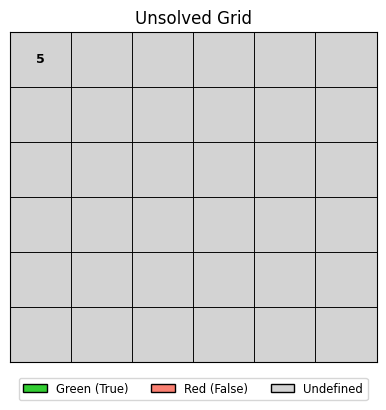

In [128]:
app = GridColoringApplication()
app.run('simple_UNSAT.txt')